# STKI RAG Demo
Demo Retrieval Augmented Generation (RAG) untuk mata kuliah STKI.


# Setup
Import libraries and initialize Gemini client

In [ ]:
import os
import time
import json
import hashlib
from pathlib import Path
import fitz
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from google import genai
import re
from transformers import AutoTokenizer
import sentence_transformers


# Load .env and get API key
load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise EnvironmentError(
        "GEMINI_API_KEY tidak ditemukan. "
        "Isi file .env dengan GEMINI_API_KEY=key-mu."
    )

client = genai.Client(api_key=GEMINI_API_KEY)

d:\Kuliah\SMT 4\STKI\STKI-RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Helper Functions
Dua fungsi utama yang dipakai berulang kali di notebook ini:
- `get_embedding` — ubah teks menjadi vektor (dengan retry + fallback lokal)
- `cosine_sim` — hitung cosine similarity antar dua vektor

In [2]:
LOCAL_EMBED_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
EMBED_CACHE_PATH = Path(".cache") / "local_embedding_cache.json"
embedding_model = sentence_transformers.SentenceTransformer(LOCAL_EMBED_MODEL)


def load_embedding_cache() -> dict[str, list[float]]:
    if EMBED_CACHE_PATH.exists():
        return json.loads(EMBED_CACHE_PATH.read_text(encoding="utf-8"))
    return {}


def save_embedding_cache(cache: dict[str, list[float]]) -> None:
    EMBED_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    EMBED_CACHE_PATH.write_text(
        json.dumps(cache, ensure_ascii=True),
        encoding="utf-8",
    )


def _cache_key(text: str, model: str = LOCAL_EMBED_MODEL) -> str:
    normalized = re.sub(r"\s+", " ", text).strip()
    return hashlib.sha256(f"{model}::{normalized}".encode("utf-8")).hexdigest()


def _embed_batch_with_retry(
    texts: list[str],
    retries: int = 4,
    base_delay: float = 1.0,
) -> list[list[float]]:
    for attempt in range(retries):
        try:
            embeddings = embedding_model.encode(
                texts,
                batch_size=max(1, min(32, len(texts))),
                show_progress_bar=False,
                normalize_embeddings=True,
                convert_to_numpy=True,
            )
            return [embedding.tolist() for embedding in embeddings]
        except Exception as exc:
            if attempt < retries - 1:
                time.sleep(base_delay * (2 ** attempt))
            else:
                raise RuntimeError(
                    f"Gagal membuat embedding batch setelah {retries} percobaan."
                ) from exc


embedding_cache = load_embedding_cache()


def get_embeddings_batch(
    texts: list[str],
    batch_size: int = 32,
    retries: int = 4,
    base_delay: float = 1.0,
) -> list[list[float]]:
    """Embed list of texts with cache + batching to reduce API calls."""
    if not texts:
        return []

    results: list[list[float] | None] = [None] * len(texts)
    misses: list[tuple[int, str, str]] = []

    for idx, text in enumerate(texts):
        key = _cache_key(text)
        cached = embedding_cache.get(key)
        if cached is not None:
            results[idx] = cached
        else:
            misses.append((idx, key, text))

    for start in range(0, len(misses), batch_size):
        batch_items = misses[start : start + batch_size]
        batch_texts = [item[2] for item in batch_items]
        batch_embeddings = _embed_batch_with_retry(
            batch_texts,
            retries=retries,
            base_delay=base_delay,
        )

        for (idx, key, _), emb in zip(batch_items, batch_embeddings):
            embedding_cache[key] = emb
            results[idx] = emb

    if misses:
        save_embedding_cache(embedding_cache)

    return [emb for emb in results if emb is not None]


def get_embedding(text: str, retries: int = 4, base_delay: float = 1.0) -> list[float]:
    """Generate single embedding using same cached batch pipeline."""
    return get_embeddings_batch(
        [text],
        batch_size=1,
        retries=retries,
        base_delay=base_delay,
    )[0]


def cosine_sim(a, b) -> float:
    """Cosine similarity between two vectors.

    Returns 0.0 if either vector is zero-length to avoid division by zero.
    """
    a, b = np.array(a), np.array(b)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)


def clean_text(text: str) -> str:
    text = text.strip()
    text = re.sub(r"[ \t]+\n", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text


def load_pdf_text(pdf_path: str):
    doc = fitz.open(pdf_path)
    text = ""

    for page in doc:
        text += page.get_text()

    return clean_text(text)


def load_md_text(file_path: Path) -> str:
    text = file_path.read_text(encoding="utf-8")
    return clean_text(text)


# pdf_text = load_pdf_text("dokumen/Buku Panduan Penulisan TA Teknologi Informasi Revisi 9.pdf")
# print(pdf_text[:200])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 580.94it/s] 


# Load Query and Documents
Tentukan query (pertanyaan) dan muat dokumen dari folder `dokumen/`.

In [3]:
query = "What is AI?"


In [4]:
BASE_DIR = Path.cwd()
DOCS_DIR = BASE_DIR / "dokumen"
print(f"BASE_DIR: {BASE_DIR}")
print(f"DOCS_DIR: {DOCS_DIR}")

BASE_DIR: d:\Kuliah\SMT 4\STKI\STKI-RAG
DOCS_DIR: d:\Kuliah\SMT 4\STKI\STKI-RAG\dokumen


In [5]:
documents_name = []
for file in DOCS_DIR.iterdir():
    if file.is_file():
        documents_name.append(file.name)
        
print(documents_name)

['Artificial-Inteligence.md', 'Climate-Change.md', 'Cyber-Security.md']


In [6]:


def load_documents() -> dict[str, str]:
    """Read all files from dokumen/ directory."""
    docs = {}
    for fname in documents_name:
        file_path = DOCS_DIR / fname
        if fname.endswith(".pdf"):
            docs[fname] = load_pdf_text(file_path)
        elif fname.endswith(".md"):
            docs[fname] = load_md_text(file_path)
        else:
            print(f"Unsupported file type: {fname}")
    return docs

DOCS = load_documents()


Query: What is AI?
Documents loaded: ['Artificial-Inteligence.md', 'Climate-Change.md', 'Cyber-Security.md']
--- Artificial-Inteligence.md ---
# Artificial Intelligence and Modern Technology

## Introduction

Artificial Intelligence (AI) has become one of the most influential
technologies of the twenty-first century. It enables computers to
perform tasks that traditionally required human intelligence, including
recognizing images, understanding natural language, making predictions,
and solving complex problems. AI is now used in education, healthcare,
transportation, finance, manufacturing, entertainment, and scientific
research.

Although AI appears to be a recent innovation, its foundations were
established decades ago through advances in mathematics, computer
science, statistics, and cognitive science. The rapid increase in
computing power, cloud infrastructure, and the availability of large
datasets has accelerated AI development dramatically.

## History of Artificial Intelligence

Preview Dokumen

In [7]:
display(pd.DataFrame(DOCS.items(), columns=["Document Name", "Content"]).head())

,Document Name,Content
0,Artificial-Inteligence.md,# Artificial Intelligence and Modern Technolog...
1,Climate-Change.md,# Climate Change\n\n## Introduction\n\nClimate...
2,Cyber-Security.md,# Cybersecurity\n\n## Introduction\n\nCybersec...


# Chunk

## Setup Chunk

In [8]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
tokenizer.model_max_length = int(1e9)

In [9]:
def chunk_text(
    text: str,
    tokenizer,
    chunk_size: int = 256,
    overlap_ratio: float = 0.2,
) -> list[str]:
    """
    Melakukan chunking berdasarkan token menggunakan Sliding Window.

    Parameters
    ----------
    text : str
        Dokumen yang akan di-chunk.
    tokenizer :
        HuggingFace tokenizer.
    chunk_size : int
        Maksimal jumlah token tiap chunk.
    overlap_ratio : float
        Persentase overlap (0.0 - 1.0).

    Returns
    -------
    list[str]
        Daftar chunk dalam bentuk teks.
    """

    # Tokenisasi
    token_ids = tokenizer.encode(
    text,
    add_special_tokens=False,
    truncation=False
)

    overlap_tokens = int(chunk_size * overlap_ratio)

    step = chunk_size - overlap_tokens

    chunks = []

    for start in range(0, len(token_ids), step):

        end = start + chunk_size

        chunk_ids = token_ids[start:end]

        if not chunk_ids:
            break

        chunk_text = tokenizer.decode(
            chunk_ids,
            skip_special_tokens=True
        )

        chunks.append(chunk_text)

    return chunks

## Proses Chunking Dokumen

In [10]:
rows = []

CHUNK_SIZE = 256
OVERLAP_RATIO = 0.3
BATCH_SIZE = 32

embedded_chunks = {}
total_chunks = 0

for doc_name, text in DOCS.items():

    chunks = chunk_text(
        text,
        tokenizer,
        chunk_size=CHUNK_SIZE,
        overlap_ratio=OVERLAP_RATIO,
    )

    unique_chunks = list(dict.fromkeys(chunks))
    unique_embeddings = get_embeddings_batch(
        unique_chunks,
        batch_size=BATCH_SIZE
    )

    unique_map = dict(zip(unique_chunks, unique_embeddings))

    chunk_embeddings = [
        unique_map[c]
        for c in chunks
    ]
    
    print(f"Document: {doc_name}, Chunks: {len(chunks)}, Unique Chunks: {len(unique_chunks)}")
    print(chunk_embeddings)

    embedded_chunks[doc_name] = {
        "chunks": chunks,
        "embeddings": chunk_embeddings,
    }

    for i, (chunk, emb) in enumerate(zip(chunks, chunk_embeddings), start=1):

        rows.append({
            "Document": doc_name,
            "Chunk": i,
            "Content": chunk[:100],
            "Embedding": str(emb[:10]) + " ..."
        })

    total_chunks += len(chunks)

df_chunks = pd.DataFrame(rows)

Document: Artificial-Inteligence.md, Chunks: 5, Unique Chunks: 5
[[-0.028180748224258423, -0.054502248764038086, -0.021398380398750305, -0.04046779125928879, 0.008849343284964561, 0.07614671438932419, 0.027008943259716034, -0.03492693975567818, 0.039921753108501434, 0.07179050147533417, 0.06247204169631004, 0.0634101927280426, 0.03506320342421532, -0.012353119440376759, -0.009109130129218102, 0.041002631187438965, -0.09208994358778, -0.06848064810037613, -0.045130323618650436, -0.05952359735965729, -0.013829266652464867, -0.06215277686715126, 0.018728887662291527, -0.06728793680667877, 0.02087649703025818, -0.018589671701192856, 0.020378369837999344, -0.00676748575642705, 0.01591009646654129, -0.060162000358104706, 0.04043680801987648, 0.00019427281222306192, 0.15571218729019165, 0.07144851982593536, -0.12763245403766632, 0.003733593737706542, -0.010344798676669598, -0.0335703045129776, -0.01797272451221943, -0.0432143397629261, -0.053352806717157364, -0.03635658323764801, 0.0842809081

In [27]:
print(embedded_chunks["Climate-Change.md"]["embeddings"])
len(embedded_chunks["Climate-Change.md"]["embeddings"][0])

[[-0.07000764459371567, 0.01800827495753765, 0.04861460253596306, 0.13593286275863647, 0.13558585941791534, 0.03322388231754303, -0.006809927523136139, -0.09857339411973953, -0.005144954659044743, 0.06092938035726547, -0.029601624235510826, 0.04935609549283981, 0.005888204090297222, -0.06144271045923233, -0.022621262818574905, -0.022165799513459206, -0.13097204267978668, -0.06681649386882782, -0.047081202268600464, -0.08937966823577881, -0.04220898449420929, 0.054635677486658096, 0.013152549043297768, 0.014483741484582424, 0.032550591975450516, -0.04860710725188255, -0.0013249949552118778, 0.009617717005312443, 0.031947072595357895, 0.03536351025104523, 0.009942712262272835, 0.08420813083648682, -0.0014084897702559829, 0.013267976231873035, -0.038820307701826096, -0.01618930511176586, -0.03867378830909729, -0.00476553151383996, -0.034748706966638565, 0.05634787678718567, 0.020395582541823387, -0.07399242371320724, 0.08105427026748657, -0.01023268885910511, -0.010918698273599148, 0.0457

384

In [12]:
display(df_chunks)

,Document,Chunk,Content,Embedding
0,Artificial-Inteligence.md,1,# artificial intelligence and modern technolog...,"[-0.028180748224258423, -0.054502248764038086,..."
1,Artificial-Inteligence.md,2,"periods of rapid growth followed by "" ai winte...","[-0.038087520748376846, -0.031207097694277763,..."
2,Artificial-Inteligence.md,3,interacting with an environment. machine learn...,"[-0.05544167384505272, 0.018289949744939804, 0..."
3,Artificial-Inteligence.md,4,- chatbots - information retrieval large langu...,"[-0.11144515872001648, 0.02009592391550541, -0..."
4,Artificial-Inteligence.md,5,is transforming nearly every aspect of society...,"[-0.0306503064930439, 0.004246686119586229, 0...."
5,Climate-Change.md,1,# climate change # # introduction climate chan...,"[-0.07000764459371567, 0.01800827495753765, 0...."
6,Climate-Change.md,2,# # environmental impacts climate change contr...,"[-0.033771999180316925, -0.015455024316906929,..."
7,Climate-Change.md,3,sustainable transportation. international agre...,"[-0.0016866613877937198, 0.013752482831478119,..."
8,Cyber-Security.md,1,# cybersecurity # # introduction cybersecurity...,"[0.0069000995717942715, -0.0009579277830198407..."
9,Cyber-Security.md,2,known as the cia triad. confidentiality ensure...,"[-0.02398616634309292, -0.027277568355202675, ..."


# Vector Search


Lakukan pencarian berbasis chunk, lalu ambil Top-K chunk paling relevan ke query.

In [28]:
TOP_K = 5

q_vec = get_embedding(query)
print(f"Query embedded: {len(q_vec)} dimensions")

chunk_rows = []
for doc_name, payload in embedded_chunks.items():
    chunks = payload["chunks"]
    embeddings = payload["embeddings"]
    for idx, (chunk_text_value, chunk_vec) in enumerate(zip(chunks, embeddings)):
        score = cosine_sim(q_vec, chunk_vec)
        chunk_rows.append(
            {
                "document": doc_name,
                "chunk_id": idx,
                "score": score,
                "chunk_text": chunk_text_value,
            }
        )

if not chunk_rows:
    raise RuntimeError("Index chunk kosong. Jalankan Cell chunk embedding terlebih dahulu.")

chunk_scores_df = pd.DataFrame(chunk_rows).sort_values(
    by="score",
    ascending=False,
    ignore_index=True,
)

top_chunks_df = chunk_scores_df.head(TOP_K).copy()
top_chunks = top_chunks_df.to_dict(orient="records")

doc_scores = (
    chunk_scores_df.groupby("document", as_index=False)["score"]
    .max()
    .sort_values(by="score", ascending=False, ignore_index=True)
    .rename(columns={"score": "best_chunk_score"})
)

best = top_chunks[0]["document"]
best_chunk = top_chunks[0]["chunk_text"]

print("Top documents by best chunk score:")
display(doc_scores)

print(f"Top {TOP_K} chunks:")
display(top_chunks_df[["document", "chunk_id", "score"]])

print("Best chunk preview:")
print(best_chunk[:500])

Query embedded: 384 dimensions
Top documents by best chunk score:


,document,best_chunk_score
0,Artificial-Inteligence.md,0.727523
1,Cyber-Security.md,0.398595
2,Climate-Change.md,0.090240


Top 5 chunks:


,document,chunk_id,score
0,Artificial-Inteligence.md,0,0.727523
1,Artificial-Inteligence.md,1,0.556243
2,Artificial-Inteligence.md,4,0.510468
3,Cyber-Security.md,2,0.398595
4,Artificial-Inteligence.md,2,0.298816


Best chunk preview:
# artificial intelligence and modern technology # # introduction artificial intelligence ( ai ) has become one of the most influential technologies of the twenty - first century. it enables computers to perform tasks that traditionally required human intelligence, including recognizing images, understanding natural language, making predictions, and solving complex problems. ai is now used in education, healthcare, transportation, finance, manufacturing, entertainment, and scientific research. al


In [31]:
top_chunks

[{'document': 'Artificial-Inteligence.md',
  'chunk_id': 0,
  'score': 0.7275229604323541,
  'chunk_text': '# artificial intelligence and modern technology # # introduction artificial intelligence ( ai ) has become one of the most influential technologies of the twenty - first century. it enables computers to perform tasks that traditionally required human intelligence, including recognizing images, understanding natural language, making predictions, and solving complex problems. ai is now used in education, healthcare, transportation, finance, manufacturing, entertainment, and scientific research. although ai appears to be a recent innovation, its foundations were established decades ago through advances in mathematics, computer science, statistics, and cognitive science. the rapid increase in computing power, cloud infrastructure, and the availability of large datasets has accelerated ai development dramatically. # # history of artificial intelligence the concept of intelligent machi

# RAG Answer Generation
Gunakan Top-K chunk hasil retrieval sebagai konteks, lalu minta Gemini menjawab secara terstruktur: ANSWER / SNIPPET / REASON.

In [35]:
METRIC = "cosine similarity on chunk embeddings"
TOP_K_CONTEXT = 3


print(f"menggunakan {TOP_K_CONTEXT} chunk sebagai konteks untuk menjawab pertanyaan: {query}")
print(f"menggunakan dokumen {best}")
selected_chunks = top_chunks[:TOP_K_CONTEXT]
context_blocks = []
for rank, item in enumerate(selected_chunks, start=1):
    print(f"menggunakan chunk_id={item['chunk_id']} score={item['score']:.4f}")
    context_blocks.append(
        f"[Chunk {rank}] doc={item['document']} chunk_id={item['chunk_id']} score={item['score']:.4f}\n"
        f"{item['chunk_text']}"
    )
context_text = "\n\n".join(context_blocks)

prompt = (
    "You are a semantic Question Answering system. "
    "Answer using ONLY the provided chunk context. "
    "If context is insufficient, say so clearly.\n\n"
    f"Query: {query}\n"
    f"Retrieval metric: {METRIC}\n"
    f"Chunk config: chunk_size={CHUNK_SIZE}, overlap_ratio={OVERLAP_RATIO}\n\n"
    f"Context:\n{context_text}\n\n"
    "Format output exactly as:\n"
    "ANSWER: ...\n"
    "SNIPPET: ...\n"
    "REASON: ..."
    )

print("Generating answer from top chunks...")
start_answer = time.time()
resp = client.models.generate_content(
    model="gemini-3.1-flash-lite",
    contents=prompt,
    )
elapsed_answer = time.time() - start_answer

# Parse structured output
lines = resp.text.strip().splitlines()
rag_result = {"answer": "", "snippet": "", "reason": ""}
current = ""
for line in lines:
    if line.startswith("ANSWER:"):
        current = "answer"
        rag_result["answer"] = line.replace("ANSWER:", "").strip()
    elif line.startswith("SNIPPET:"):
        current = "snippet"
        rag_result["snippet"] = line.replace("SNIPPET:", "").strip()
    elif line.startswith("REASON:"):
        current = "reason"
        rag_result["reason"] = line.replace("REASON:", "").strip()
    elif current == "answer" and line.strip():
        rag_result["answer"] += " " + line.strip()
    elif current == "snippet" and line.strip():
        rag_result["snippet"] += " " + line.strip()
    elif current == "reason" and line.strip():
        rag_result["reason"] += " " + line.strip()

print("ANSWER:", rag_result["answer"])
print("SNIPPET:", rag_result["snippet"])
print("REASON:", rag_result["reason"])
print(f"[Generated in {elapsed_answer:.2f}s]")

menggunakan 3 chunk sebagai konteks untuk menjawab pertanyaan: What is AI?
menggunakan dokumen Artificial-Inteligence.md
menggunakan chunk_id=0 score=0.7275
menggunakan chunk_id=1 score=0.5562
menggunakan chunk_id=4 score=0.5105
Generating answer from top chunks...
ANSWER: Artificial intelligence (AI) is a technology that enables computers to perform tasks traditionally requiring human intelligence, such as recognizing images, understanding natural language, making predictions, and solving complex problems.
SNIPPET: "artificial intelligence ( ai ) has become one of the most influential technologies of the twenty - first century. it enables computers to perform tasks that traditionally required human intelligence, including recognizing images, understanding natural language, making predictions, and solving complex problems."
REASON: The provided context in Chunk 1 explicitly defines AI and its capabilities, which directly answers the query.
[Generated in 1.12s]


# Chunking Hyperparameter Sweep
Bandingkan beberapa kombinasi `chunk_size` dan `overlap_ratio` dengan beberapa query representatif, lalu agregasikan metrik retrieval-nya.

In [38]:
GRID_CHUNK_SIZES = [50,100, 256, 384, 512, 768, 1024]
GRID_OVERLAPS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
TOP_K_EVAL = 5
EVAL_QUERIES = [
    {
        "name": "ai_basic",
        "query": "What is artificial intelligence?",
        "target_document": "Artificial-Inteligence.md",
    },
    {
        "name": "ai_paraphrase",
        "query": "Explain AI in simple terms.",
        "target_document": "Artificial-Inteligence.md",
    },
    {
        "name": "climate_basic",
        "query": "What causes climate change?",
        "target_document": "Climate-Change.md",
    },
    {
        "name": "climate_paraphrase",
        "query": "How does global warming affect the environment?",
        "target_document": "Climate-Change.md",
    },
    {
        "name": "cyber_basic",
        "query": "What are common cybersecurity threats?",
        "target_document": "Cyber-Security.md",
    },
    {
        "name": "cyber_paraphrase",
        "query": "How can we protect systems from attacks?",
        "target_document": "Cyber-Security.md",
    },
]

def build_chunk_index(docs: dict[str, str], chunk_size: int, overlap_ratio: float):
    raw_rows = []
    unique_chunks = []
    seen_chunks = set()

    for doc_name, text in docs.items():
        chunks = chunk_text(
            text,
            tokenizer,
            chunk_size=chunk_size,
            overlap_ratio=overlap_ratio,
        )

        for idx, chunk_text_value in enumerate(chunks):
            raw_rows.append((doc_name, idx, chunk_text_value))
            if chunk_text_value not in seen_chunks:
                seen_chunks.add(chunk_text_value)
                unique_chunks.append(chunk_text_value)

    unique_embeddings = get_embeddings_batch(unique_chunks, batch_size=BATCH_SIZE)
    emb_map = dict(zip(unique_chunks, unique_embeddings))

    chunk_index = []
    for doc_name, idx, chunk_text_value in raw_rows:
        chunk_index.append(
            {
                "document": doc_name,
                "chunk_id": idx,
                "chunk_text": chunk_text_value,
                "embedding": emb_map[chunk_text_value],
            }
        )

    return chunk_index, len(raw_rows), len(unique_chunks)


def evaluate_chunking_grid(
    docs: dict[str, str],
    chunk_sizes: list[int],
    overlaps: list[float],
    top_k: int = 5,
):
    eval_rows = []

    for chunk_size in chunk_sizes:
        for overlap in overlaps:
            index_rows, total_chunks, unique_chunks = build_chunk_index(
                docs,
                chunk_size=chunk_size,
                overlap_ratio=overlap,
            )

            per_query_rows = []
            for item in EVAL_QUERIES:
                q_vec = get_embedding(item["query"])
                q_scored = sorted(
                    [
                        {**row, "score": cosine_sim(q_vec, row["embedding"]) }
                        for row in index_rows
                    ],
                    key=lambda x: x["score"],
                    reverse=True,
                )
                q_top_items = q_scored[:top_k]
                q_top1 = q_top_items[0] if q_top_items else None
                q_top1_score = q_top1["score"] if q_top1 else 0.0
                q_mean_topk = (
                    sum(row["score"] for row in q_top_items) / len(q_top_items)
                    if q_top_items
                    else 0.0
                )
                q_hit = 1.0 if q_top1 and q_top1["document"] == item["target_document"] else 0.0
                q_rank = next(
                    (i + 1 for i, row in enumerate(q_scored) if row["document"] == item["target_document"]),
                    None,
                )
                q_mrr = 1.0 / q_rank if q_rank else 0.0
                per_query_rows.append(
                    {
                        "query_name": item["name"],
                        "query_text": item["query"],
                        "target_document": item["target_document"],
                        "top1_score": q_top1_score,
                        "mean_topk_score": q_mean_topk,
                        "hit_at_1": q_hit,
                        "mrr": q_mrr,
                        "top_document": q_top1["document"] if q_top1 else None,
                        "top_chunk_preview": (
                            q_top1["chunk_text"][:160].replace("\n", " ")
                            if q_top1
                            else ""
                        ),
                    }
                )

            per_query_df = pd.DataFrame(per_query_rows)
            est_requests = (unique_chunks + BATCH_SIZE - 1) // BATCH_SIZE

            eval_rows.append(
                {
                    "chunk_size": chunk_size,
                    "overlap_ratio": overlap,
                    "total_chunks": total_chunks,
                    "unique_chunks": unique_chunks,
                    "est_embed_requests": est_requests,
                    "queries": len(EVAL_QUERIES),
                    "avg_top1_score": per_query_df["top1_score"].mean(),
                    "avg_mean_topk_score": per_query_df["mean_topk_score"].mean(),
                    "hit_at_1": per_query_df["hit_at_1"].mean(),
                    "mrr": per_query_df["mrr"].mean(),
                    "score_stability": per_query_df["top1_score"].std(ddof=0),
                    "per_query_detail": per_query_df.to_dict(orient="records"),
                }
            )

    result_df = pd.DataFrame(eval_rows).sort_values(
        by=["hit_at_1", "mrr", "avg_top1_score"],
        ascending=False,
        ignore_index=True,
    )
    return result_df


grid_result_df = evaluate_chunking_grid(
    docs=DOCS,
    chunk_sizes=GRID_CHUNK_SIZES,
    overlaps=GRID_OVERLAPS,
    top_k=TOP_K_EVAL,
    )

display(
    grid_result_df[
        [
            "chunk_size",
            "overlap_ratio",
            "total_chunks",
            "unique_chunks",
            "est_embed_requests",
            "queries",
            "hit_at_1",
            "mrr",
            "avg_top1_score",
            "avg_mean_topk_score",
            "score_stability",
        ]
    ]
)

print("Best config:")
display(grid_result_df.head(1))

print("Best config detail per query:")
display(pd.DataFrame(grid_result_df.iloc[0]["per_query_detail"]))

,chunk_size,overlap_ratio,total_chunks,unique_chunks,est_embed_requests,queries,hit_at_1,mrr,avg_top1_score,avg_mean_topk_score,score_stability
0,100,0.30,27,27,1,6,1.0,1.0,0.755553,0.642619,0.084601
1,50,0.50,73,73,3,6,1.0,1.0,0.743910,0.683553,0.073922
2,50,0.30,53,53,2,6,1.0,1.0,0.743522,0.663864,0.069065
3,100,0.40,31,31,1,6,1.0,1.0,0.740140,0.656759,0.084610
4,100,0.20,24,24,1,6,1.0,1.0,0.736420,0.627440,0.085999
5,100,0.50,37,37,2,6,1.0,1.0,0.734599,0.665108,0.092015
6,50,0.20,47,47,2,6,1.0,1.0,0.732015,0.659835,0.071116
7,50,0.40,61,61,2,6,1.0,1.0,0.728315,0.672200,0.076657
8,100,0.05,21,21,1,6,1.0,1.0,0.726122,0.629894,0.079913
9,50,0.05,40,40,2,6,1.0,1.0,0.715044,0.635287,0.071043


Best config:


,chunk_size,overlap_ratio,total_chunks,unique_chunks,est_embed_requests,queries,avg_top1_score,avg_mean_topk_score,hit_at_1,mrr,score_stability,per_query_detail
0,100,0.3,27,27,1,6,0.755553,0.642619,1.0,1.0,0.084601,"[{'query_name': 'ai_basic', 'query_text': 'Wha..."


Best config detail per query:


,query_name,query_text,target_document,top1_score,mean_topk_score,hit_at_1,mrr,top_document,top_chunk_preview
0,ai_basic,What is artificial intelligence?,Artificial-Inteligence.md,0.755779,0.636508,1.0,1.0,Artificial-Inteligence.md,# artificial intelligence and modern technolog...
1,ai_paraphrase,Explain AI in simple terms.,Artificial-Inteligence.md,0.625349,0.525221,1.0,1.0,Artificial-Inteligence.md,# artificial intelligence and modern technolog...
2,climate_basic,What causes climate change?,Climate-Change.md,0.867551,0.689939,1.0,1.0,Climate-Change.md,"to rise. climate change affects ecosystems, ec..."
3,climate_paraphrase,How does global warming affect the environment?,Climate-Change.md,0.766531,0.684300,1.0,1.0,Climate-Change.md,"to rise. climate change affects ecosystems, ec..."
4,cyber_basic,What are common cybersecurity threats?,Cyber-Security.md,0.840610,0.713498,1.0,1.0,Cyber-Security.md,"combines technology, organizational policies, ..."
5,cyber_paraphrase,How can we protect systems from attacks?,Cyber-Security.md,0.677499,0.606246,1.0,1.0,Cyber-Security.md,"combines technology, organizational policies, ..."


## Cell 7: Visualization and Summary
Tampilkan hasil grid search dalam bentuk grafik sederhana dan ringkasan eksperimen.

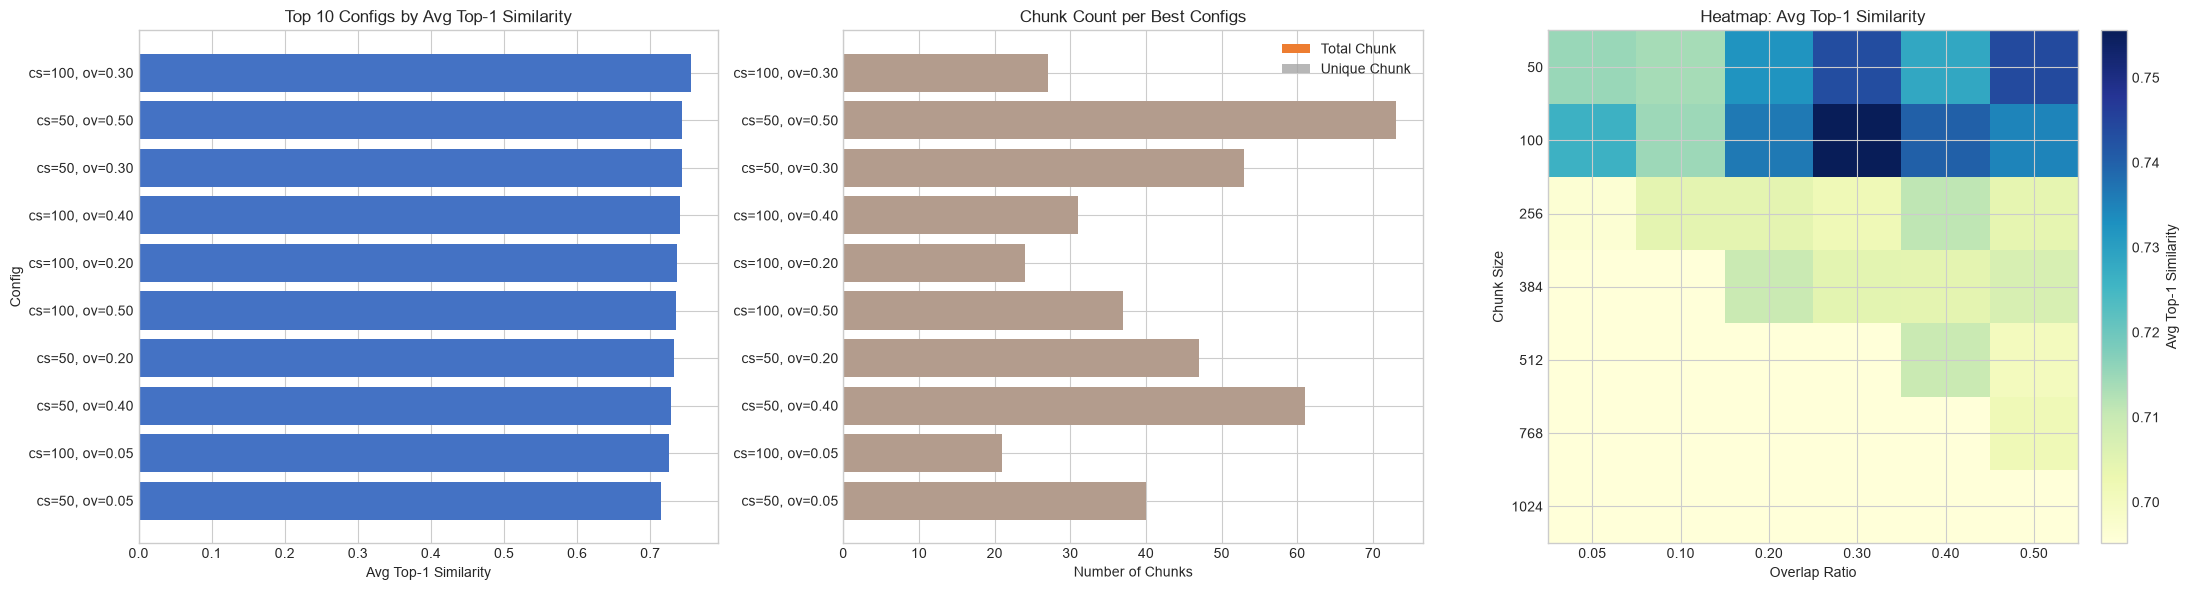

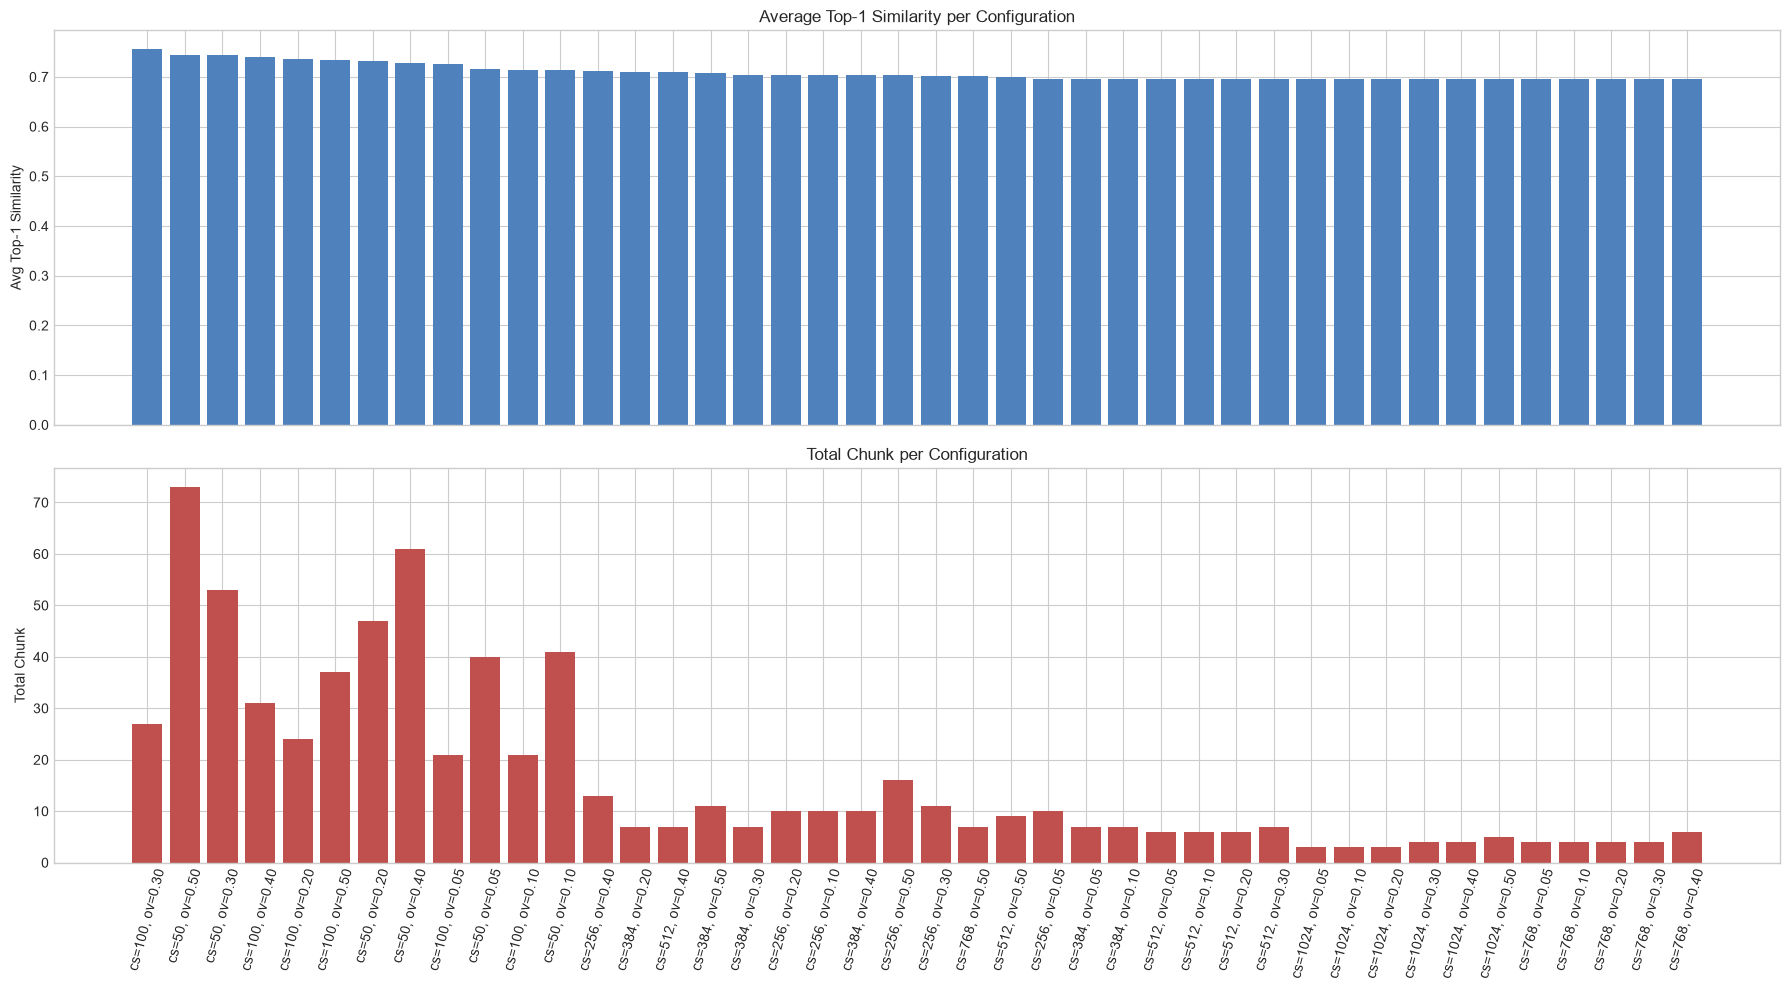

Best configuration:


,chunk_size,overlap_ratio,total_chunks,unique_chunks,est_embed_requests,queries,avg_top1_score,avg_mean_topk_score,hit_at_1,mrr,score_stability,per_query_detail
0,100,0.3,27,27,1,6,0.755553,0.642619,1.0,1.0,0.084601,"[{'query_name': 'ai_basic', 'query_text': 'Wha..."


Best configuration detail per query:


,query_name,query_text,target_document,top1_score,mean_topk_score,hit_at_1,mrr,top_document,top_chunk_preview
0,ai_basic,What is artificial intelligence?,Artificial-Inteligence.md,0.755779,0.636508,1.0,1.0,Artificial-Inteligence.md,# artificial intelligence and modern technolog...
1,ai_paraphrase,Explain AI in simple terms.,Artificial-Inteligence.md,0.625349,0.525221,1.0,1.0,Artificial-Inteligence.md,# artificial intelligence and modern technolog...
2,climate_basic,What causes climate change?,Climate-Change.md,0.867551,0.689939,1.0,1.0,Climate-Change.md,"to rise. climate change affects ecosystems, ec..."
3,climate_paraphrase,How does global warming affect the environment?,Climate-Change.md,0.766531,0.684300,1.0,1.0,Climate-Change.md,"to rise. climate change affects ecosystems, ec..."
4,cyber_basic,What are common cybersecurity threats?,Cyber-Security.md,0.840610,0.713498,1.0,1.0,Cyber-Security.md,"combines technology, organizational policies, ..."
5,cyber_paraphrase,How can we protect systems from attacks?,Cyber-Security.md,0.677499,0.606246,1.0,1.0,Cyber-Security.md,"combines technology, organizational policies, ..."


Chunk size summary:


,chunk_size,unique_chunks,avg_top1_score,hit_at_1,mrr
0,50,52.500000,0.729400,1.0,1.0
1,100,26.833333,0.734595,1.0,1.0
2,256,11.666667,0.703641,1.0,1.0
3,384,8.166667,0.702686,1.0,1.0
4,512,6.833333,0.698406,1.0,1.0
5,768,4.833333,0.696252,1.0,1.0
6,1024,3.666667,0.695178,1.0,1.0


Overlap ratio summary:


,overlap_ratio,unique_chunks,avg_top1_score,hit_at_1,mrr
0,0.05,13.000000,0.702589,1.0,1.0
1,0.10,13.142857,0.701919,1.0,1.0
2,0.20,14.428571,0.709724,1.0,1.0
3,0.30,16.142857,0.712983,1.0,1.0
4,0.40,18.857143,0.711988,1.0,1.0
5,0.50,22.571429,0.712360,1.0,1.0


Ringkasan hasil eksperimen:
- Konfigurasi terbaik: chunk_size=100, overlap_ratio=0.30
- Rata-rata Hit@1 terbaik: 1.000
- Rata-rata MRR terbaik: 1.000
- Average Top-1 Similarity terbaik: 0.7556
- Total chunk pada konfigurasi terbaik: 27
- Unique chunk pada konfigurasi terbaik: 27
- Chunk size yang lebih besar cenderung mengurangi jumlah chunk, tetapi bisa menurunkan resolusi detail jika terlalu besar.
- Overlap yang lebih tinggi biasanya menaikkan jumlah chunk dan bisa membantu similarity, tetapi juga menambah biaya indexing.
- Trade-off utamanya: konfigurasi dengan chunk lebih kecil dan overlap tinggi memberi konteks lebih detail, namun menghasilkan lebih banyak chunk dan embedding request.


In [39]:
# Build a readable label for each configuration
import matplotlib.pyplot as plt
_ = plt
plot_df = grid_result_df.copy()
plot_df["config"] = plot_df.apply(
    lambda row: f"cs={row['chunk_size']}, ov={row['overlap_ratio']:.2f}",
    axis=1,
 )
plot_df = plot_df.reset_index(drop=True)

# Prepare summary tables
best_config = grid_result_df.iloc[0]
chunk_size_summary = (
    grid_result_df.groupby("chunk_size", as_index=False)[["unique_chunks", "avg_top1_score", "hit_at_1", "mrr"]]
    .mean()
    .sort_values(by="chunk_size")
 )
overlap_summary = (
    grid_result_df.groupby("overlap_ratio", as_index=False)[["unique_chunks", "avg_top1_score", "hit_at_1", "mrr"]]
    .mean()
    .sort_values(by="overlap_ratio")
 )

# Plot settings
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1) Average Top-1 Similarity by config
top_plot = plot_df.sort_values(
    by=["hit_at_1", "mrr", "avg_top1_score"],
    ascending=False,
).head(10)
axes[0].barh(top_plot["config"][::-1], top_plot["avg_top1_score"][::-1], color="#4472C4")
axes[0].set_title("Top 10 Configs by Avg Top-1 Similarity")
axes[0].set_xlabel("Avg Top-1 Similarity")
axes[0].set_ylabel("Config")

# 2) Total/Unique chunks by config
axes[1].barh(top_plot["config"][::-1], top_plot["total_chunks"][::-1], color="#ED7D31", label="Total Chunk")
axes[1].barh(top_plot["config"][::-1], top_plot["unique_chunks"][::-1], color="#A5A5A5", alpha=0.8, label="Unique Chunk")
axes[1].set_title("Chunk Count per Best Configs")
axes[1].set_xlabel("Number of Chunks")
axes[1].legend()

# 3) Heatmap of Avg Top-1 Similarity
heatmap_data = grid_result_df.pivot(index="chunk_size", columns="overlap_ratio", values="avg_top1_score")
im = axes[2].imshow(heatmap_data.values, aspect="auto", cmap="YlGnBu")
axes[2].set_title("Heatmap: Avg Top-1 Similarity")
axes[2].set_xticks(range(len(heatmap_data.columns)))
axes[2].set_xticklabels([f"{x:.2f}" for x in heatmap_data.columns])
axes[2].set_yticks(range(len(heatmap_data.index)))
axes[2].set_yticklabels(heatmap_data.index)
axes[2].set_xlabel("Overlap Ratio")
axes[2].set_ylabel("Chunk Size")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="Avg Top-1 Similarity")

plt.tight_layout()
plt.show()

# Secondary bar charts for all configurations (compact view)
fig2, axes2 = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
axes2[0].bar(plot_df["config"], plot_df["avg_top1_score"], color="#4F81BD")
axes2[0].set_title("Average Top-1 Similarity per Configuration")
axes2[0].set_ylabel("Avg Top-1 Similarity")
axes2[0].tick_params(axis="x", rotation=75)

axes2[1].bar(plot_df["config"], plot_df["total_chunks"], color="#C0504D")
axes2[1].set_title("Total Chunk per Configuration")
axes2[1].set_ylabel("Total Chunk")
axes2[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

print("Best configuration:")
display(grid_result_df.head(1))

print("Best configuration detail per query:")
display(pd.DataFrame(grid_result_df.iloc[0]["per_query_detail"]))

print("Chunk size summary:")
display(chunk_size_summary)

print("Overlap ratio summary:")
display(overlap_summary)

print("Ringkasan hasil eksperimen:")
print(f"- Konfigurasi terbaik: chunk_size={int(best_config['chunk_size'])}, overlap_ratio={best_config['overlap_ratio']:.2f}")
print(f"- Rata-rata Hit@1 terbaik: {best_config['hit_at_1']:.3f}")
print(f"- Rata-rata MRR terbaik: {best_config['mrr']:.3f}")
print(f"- Average Top-1 Similarity terbaik: {best_config['avg_top1_score']:.4f}")
print(f"- Total chunk pada konfigurasi terbaik: {int(best_config['total_chunks'])}")
print(f"- Unique chunk pada konfigurasi terbaik: {int(best_config['unique_chunks'])}")
print("- Chunk size yang lebih besar cenderung mengurangi jumlah chunk, tetapi bisa menurunkan resolusi detail jika terlalu besar.")
print("- Overlap yang lebih tinggi biasanya menaikkan jumlah chunk dan bisa membantu similarity, tetapi juga menambah biaya indexing.")
print("- Trade-off utamanya: konfigurasi dengan chunk lebih kecil dan overlap tinggi memberi konteks lebih detail, namun menghasilkan lebih banyak chunk dan embedding request.")